# Data Project

> **Note:** 
> 1. This is a starting point for how to structure your data project 
> 1. The `dataproject.py` file includes functions which can be in this notebook

Import and set magics:

test test

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
!{sys.executable} -m pip install git+https://github.com/alemartinello/dstapi
!{sys.executable} -m pip install fredapi pandas-datareader

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import dataproject

  Cloning https://github.com/alemartinello/dstapi to /private/var/folders/kv/fqcxp2_17nj86g1k_wl1r2w00000gn/T/pip-req-build-mcqt4zuy
  Running command git clone --filter=blob:none --quiet https://github.com/alemartinello/dstapi /private/var/folders/kv/fqcxp2_17nj86g1k_wl1r2w00000gn/T/pip-req-build-mcqt4zuy
  Resolved https://github.com/alemartinello/dstapi to commit d9eeb5a82cbc70b7d63b2ff44d92632fd77123a4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Question 1

We load the data from...

In [41]:
from dstapi import DstApi

IFOR41 = DstApi('IFOR41')
IFOR41.tablesummary(language='en')


Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [42]:
IFOR41.variable_levels('ULLIG',language='en') 

,id,text
0,70,Gini coefficient
1,71,Hoover index
2,72,S80/S20 (Income quintile share ratio)
3,73,P90/10 (Upper decile boundary divided by lower)


In [43]:
params1 = {
    'table': 'IFOR41',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']}, 
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

gini = IFOR41.get_data(params=params1)

display(gini.head(10))
display(gini.info())

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93
5,Gini coefficient,All Denmark,2008,27.94
6,Gini coefficient,All Denmark,1994,22.50
7,Gini coefficient,All Denmark,2021,30.28
8,Gini coefficient,All Denmark,2011,27.68
9,Gini coefficient,All Denmark,2009,26.74


<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ULLIG      38 non-null     str  
 1   KOMMUNEDK  38 non-null     str  
 2   TID        38 non-null     int64
 3   INDHOLD    38 non-null     str  
dtypes: int64(1), str(3)
memory usage: 2.5 KB


None

In [44]:
gini['INDHOLD'] = pd.to_numeric(gini['INDHOLD'])

# Clean the data and rename columns for clarity (clean of ULLIG and INDEHOLD , so we only have TID and GINI)
gini_clean = gini[['TID', 'INDHOLD']].copy()
gini_clean = gini_clean.rename(columns={'INDHOLD': 'GINI'})

gini_clean = gini_clean.sort_values('TID')

display(gini_clean.head(38))

,TID,GINI
16,1987,22.07
2,1988,22.06
4,1989,21.93
30,1990,22.16
25,1991,21.99
19,1992,22.34
34,1993,22.79
6,1994,22.50
36,1995,22.41
15,1996,22.83


In [45]:
from dstapi import DstApi

IFOR32 = DstApi('IFOR32')
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [46]:
IFOR32.variable_levels('DECILGEN',language='en') 

,id,text
0,1DC,First decil
1,2DC,Second decil
2,3DC,Third decil
3,4DC,Fourth decil
4,5DC,Fifth decil
5,6DC,Sixth decil
6,7DC,Seventh decil
7,8DC,Eigth decil
8,9DC,Ninth decil
9,10DC,Tenth decil


In [47]:
params2 = {
    'table': 'IFOR32',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']}, 
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

deciles = IFOR32.get_data(params=params2)

display(deciles.head(10))
display(deciles.info())

,DECILGEN,KOMMUNEDK,TID,INDHOLD
0,First decil,All Denmark,2013,75704
1,Second decil,All Denmark,2013,140049
2,Third decil,All Denmark,2013,163582
3,Fourth decil,All Denmark,2013,185931
4,Fifth decil,All Denmark,2013,209384
5,Sixth decil,All Denmark,2013,233523
6,Seventh decil,All Denmark,2013,260360
7,Eigth decil,All Denmark,2013,293590
8,Ninth decil,All Denmark,2013,342855
9,Tenth decil,All Denmark,2013,560961


<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   DECILGEN   380 non-null    str  
 1   KOMMUNEDK  380 non-null    str  
 2   TID        380 non-null    int64
 3   INDHOLD    380 non-null    int64
dtypes: int64(2), str(2)
memory usage: 20.3 KB


None

In [48]:
# Total income for each year
total_income = deciles.groupby('TID')['INDHOLD'].sum()

# Income of the richest 10 percent
richest = deciles[deciles['DECILGEN'] == 'Tenth decil'].set_index('TID')['INDHOLD']

# Top 10 percent share
top10 = richest / total_income * 100

print(top10)

TID
1987    18.454866
1988    18.428870
1989    18.495170
1990    18.641480
1991    18.668346
1992    18.824050
1993    19.213004
1994    19.082992
1995    19.296649
1996    19.613977
1997    20.212349
1998    20.349233
1999    20.293497
2000    20.810058
2001    20.722210
2002    20.441865
2003    20.406410
2004    20.718309
2005    21.549831
2006    22.251229
2007    22.630255
2008    21.799734
2009    20.933498
2010    21.918315
2011    22.161128
2012    22.264327
2013    22.748373
2014    22.782468
2015    23.451122
2016    23.383232
2017    23.671866
2018    23.381490
2019    24.005495
2020    24.007665
2021    24.727627
2022    24.357469
2023    25.282340
2024    25.121443
Name: INDHOLD, dtype: float64


In [49]:
#använd inner join för att kombinera gini_clean och top10 i en ny DataFrame som heter combined_data.

merged = pd.merge(
    gini_clean,
    top10,
    on='TID',
    how='inner',
    validate='1:1') 

print(merged)

     TID   GINI    INDHOLD
0   1987  22.07  18.454866
1   1988  22.06  18.428870
2   1989  21.93  18.495170
3   1990  22.16  18.641480
4   1991  21.99  18.668346
5   1992  22.34  18.824050
6   1993  22.79  19.213004
7   1994  22.50  19.082992
8   1995  22.41  19.296649
9   1996  22.83  19.613977
10  1997  23.47  20.212349
11  1998  23.81  20.349233
12  1999  23.83  20.293497
13  2000  24.38  20.810058
14  2001  24.40  20.722210
15  2002  24.03  20.441865
16  2003  24.14  20.406410
17  2004  24.68  20.718309
18  2005  25.66  21.549831
19  2006  26.28  22.251229
20  2007  27.02  22.630255
21  2008  27.94  21.799734
22  2009  26.74  20.933498
23  2010  27.47  21.918315
24  2011  27.68  22.161128
25  2012  27.37  22.264327
26  2013  27.88  22.748373
27  2014  28.33  22.782468
28  2015  28.77  23.451122
29  2016  28.97  23.383232
30  2017  29.32  23.671866
31  2018  29.10  23.381490
32  2019  29.55  24.005495
33  2020  29.72  24.007665
34  2021  30.28  24.727627
35  2022  29.96  24.357469
3

In [50]:
data = dataproject.load_data()

## Question 2

We process the data by ...

In [51]:
data = dataproject.process_data(data)

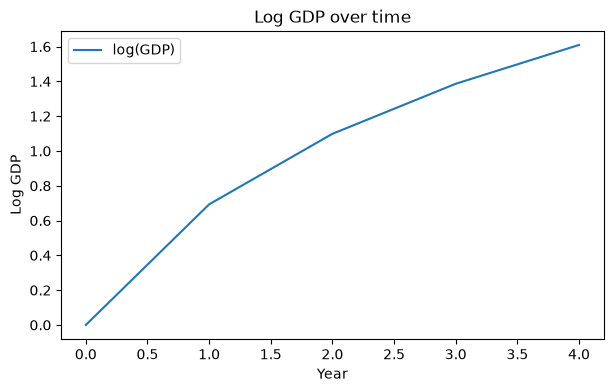

In [52]:
fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(111)

ax.plot(data['log_GDP'],label='log(GDP)')

ax.set_title('Log GDP over time')
ax.set_xlabel('Year')
ax.set_ylabel('Log GDP')

ax.legend();

We find that that ...

In [53]:
par = incomemodel.Parameters()
sim = incomemodel.simulate(par)

NameError: name 'incomemodel' is not defined

In [ ]:
# Check that the simulation is correct
_ = incomemodel.check_simulation(sim)

incomemodel.plot_lifecycle(sim);

incomemodel.plot_histograms(sim, ages=(25,35,45,60));